In [ ]:
!pip install ultralytics -q
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
  print("Device:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00
GPU available: True
Device: Tesla T4


In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
import os
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo
!unzip -q icg-spacenet-sandox-yolo.zip -d /content/
print("Done.")


Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:14<00:00, 67.1MB/s]

Done.


In [ ]:
!find /content -maxdepth 3 -type d | grep -iE 'image|label|train|val|test'
import glob
print("Images:", len(glob.glob('/content/**/*.png', recursive=True)))
print("Labels:", len(glob.glob('/content/**/*.txt', recursive=True)))

/content/spacenet_buildings_yolo/labels
/content/spacenet_buildings_yolo/images
Images: 1148
Labels: 1148


No train/test/val folders yet, will be created later. The number of images and labels are both same.

In [ ]:
!ls

icg-spacenet-sandox-yolo.zip  kaggle.json  sample_data	spacenet_buildings_yolo


Still a .zip file sitting.

In [ ]:
!unzip /content/icg-spacenet-sandox-yolo.zip

Archive:  /content/icg-spacenet-sandox-yolo.zip
replace spacenet_buildings_yolo/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: spacenet_buildings_yolo/README.md  
  inflating: spacenet_buildings_yolo/dataset.yaml.template  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img10.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img100.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1000.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1001.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1003.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1007.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1008.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1009.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img101.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1010.png  
  inflating: spacenet_buildings_yolo/images/AOI_3_Paris_img1011

Unzipped!

In [ ]:
!find /content -maxdepth 3 -type d | grep -iE 'image|label|train|val|test'
import glob
print("Images:", len(glob.glob('/content/**/*.png', recursive=True)))
print("Labels:", len(glob.glob('/content/**/*.txt', recursive=True)))

/content/spacenet_buildings_yolo/labels
/content/spacenet_buildings_yolo/images
Images: 1148
Labels: 1148


Total Images: 1148


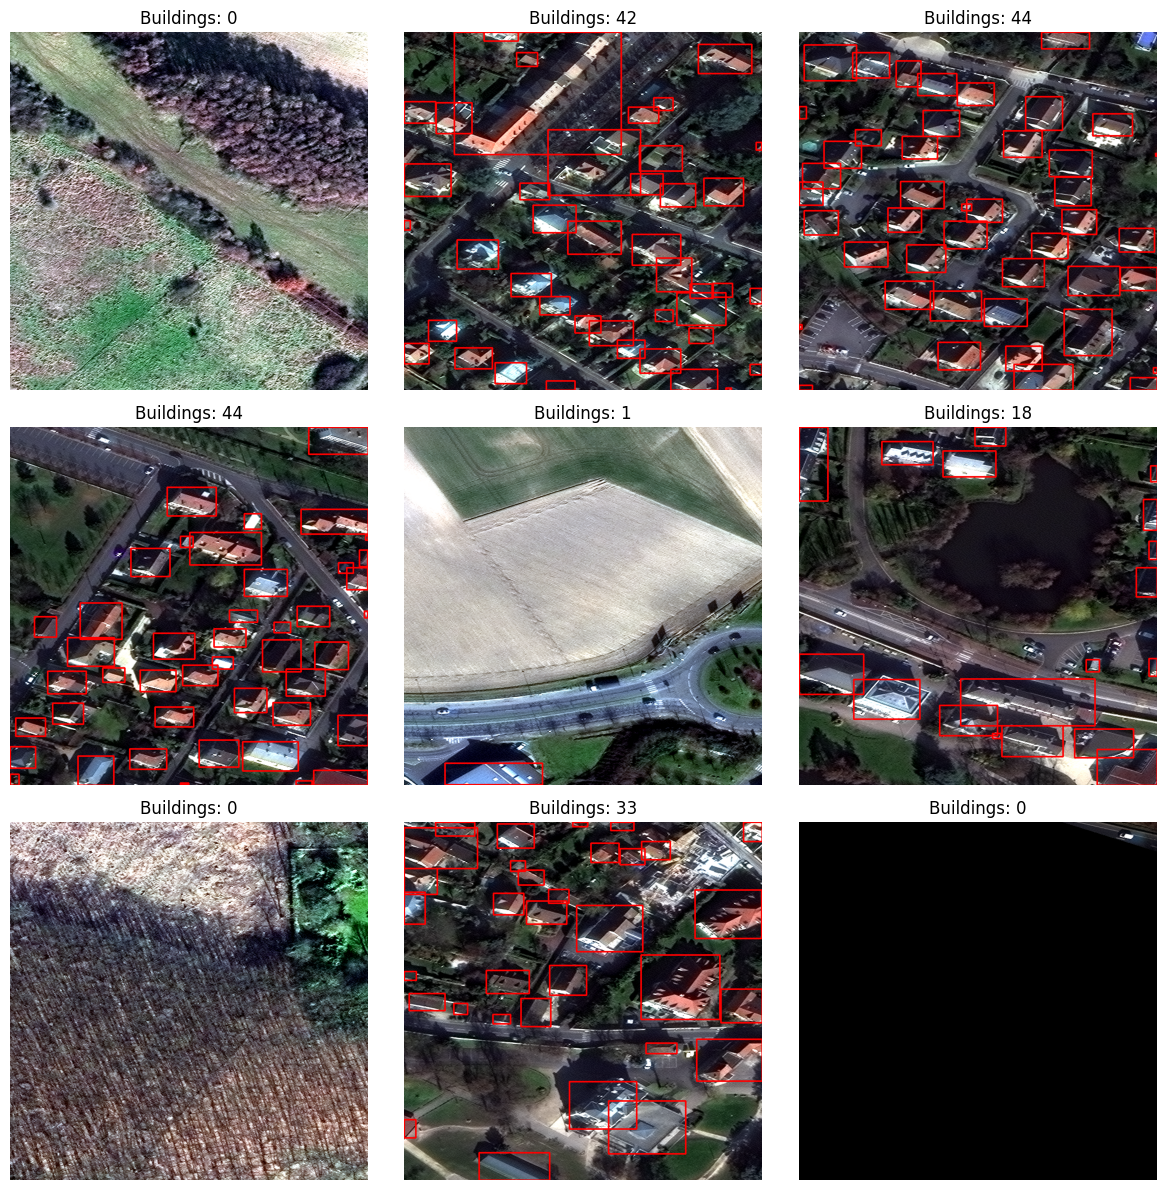

Average buildings per image: 14.49


In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
img_paths=glob.glob('/content/spacenet_buildings_yolo/images/*.png')
print("Total Images:", len(img_paths))
#9 random images
random_imgs=random.sample(img_paths, 9)
fig, axes=plt.subplots(3, 3,figsize=(12,12))
for ax, img_path in zip(axes.flatten(), random_imgs):
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _=img.shape
    base_name=os.path.splitext(os.path.basename(img_path))[0]
    label_path=f'/content/spacenet_buildings_yolo/labels/{base_name}.txt'
    building_count=0
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines=f.readlines()
        for line in lines:
            line = line.strip()
            if not line:
                continue
            building_count+=1
            cls, cx, cy, w, h=map(float, line.split())
            # Conversion of YOLO → pixel coordinates
            x1=int((cx-w/2)*W)
            y1=int((cy-h/2)*H)
            x2=int((cx+w/2)*W)
            y2=int((cy+h/2)*H)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    ax.imshow(img)
    ax.set_title(f"Buildings: {building_count}")
    ax.axis('off')
plt.tight_layout()
plt.show()
label_files=glob.glob('/content/spacenet_buildings_yolo/labels/*.txt')
total_buildings=0
for file in label_files:
    with open(file, 'r') as f:
        lines=[line for line in f.readlines() if line.strip()]
        total_buildings+=len(lines)
avg_buildings = total_buildings / len(label_files)
print("Average buildings per image:", round(avg_buildings, 2))

1) Average number of buildings per image=14.49 that is roughly 14 per image.

2) Most images appear consistent in spatial size and resolution. However, image quality varies slightly due to vegetation coverage, and partial image tiles. Some images also contain dark or incomplete regions near boundaries.

3) The model may face several challenges because of following:
    
    Dense clusters of buildings causing overlapping bounding boxes
    
    Small rooftops that are difficult to detect
    
    Shadows from trees or buildings obscuring rooftops
    
    Dark or incomplete regions entirely or near boundaries
    
    Similar textures between buildings and surrounding structures

In [ ]:
import shutil
SRC='/content/spacenet_buildings_yolo'
BASE='/content/dataset'
imgs=glob.glob(f'{SRC}/images/*.png')
random.seed(42)
random.shuffle(imgs)
splits=['train', 'val', 'test']
for split in splits:
    os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)
n=len(imgs)
train_end=int(0.8*n)
val_end=int(0.9 * n)
train_imgs=imgs[:train_end]
val_imgs=imgs[train_end:val_end]
test_imgs=imgs[val_end:]
split_data={'train': train_imgs, 'val': val_imgs, 'test': test_imgs}
# Copying files
for split, split_imgs in split_data.items():
    for img_path in split_imgs:
        filename=os.path.basename(img_path)
        # Copying image
        shutil.copy(img_path, f'{BASE}/images/{split}/{filename}')
        # Matching label
        stem=os.path.splitext(filename)[0]
        label_src=f'{SRC}/labels/{stem}.txt'
        label_dst=f'{BASE}/labels/{split}/{stem}.txt'
        # Copy label if exists
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)
        # Else create empty.txt
        else:
            open(label_dst, 'w').close()
print("Train", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

Train 918
Val: 115
Test: 115


The split is clearly roughly 80/10/10.

In [ ]:
yaml_content = f"""path: {BASE}
train: images/train
val: images/val
test: images/test
nc: 1
names: ['building']
"""
with open(f"{BASE}/dataset.yaml", "w") as f:
    f.write(yaml_content)
print("dataset.yaml created!")

dataset.yaml created!


We load `yolov8s.pt` instead of starting from random weights because the model has already learned useful visual features from large datasets like COCO. This process is called transfer learning. Using pretrained weights helps the model converge faster, improves accuracy, and requires less training data compared to training from scratch.


In [ ]:
from ultralytics import YOLO
model=YOLO("yolov8s.pt")
results=model.train(data="/content/dataset/dataset.yaml", epochs=25, imgsz=640,
batch=16, name="building_detector")
import pandas as pd
df=pd.read_csv("/content/runs/detect/building_detector/results.csv")
print("Final box_loss:", df["train/box_loss"].iloc[-1])
print("Final mAP50:", df["metrics/mAP50(B)"].iloc[-1])


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

For the last epoch, final box loss is 1.233 and final mAP50 is 0.842.

In [ ]:
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,29.7944,1.79132,1.75454,1.37865,0.73520,0.62811,0.69734,0.37828,1.50076,1.29191,1.35276,0.000655,0.000655,0.000655
1,2,53.8277,1.54775,1.09503,1.24602,0.78979,0.64505,0.72308,0.39738,1.51191,1.31546,1.29185,0.001269,0.001269,0.001269
2,3,79.2379,1.55529,1.07966,1.25057,0.46894,0.34422,0.33443,0.17617,1.63824,1.99117,1.44092,0.001831,0.001831,0.001831
3,4,104.4860,1.53386,1.08945,1.26188,0.76923,0.67933,0.74891,0.41079,1.50095,1.22573,1.27526,0.001762,0.001762,0.001762
4,5,129.9820,1.53262,1.05468,1.25064,0.80966,0.68016,0.76376,0.43823,1.42986,1.02064,1.25525,0.001683,0.001683,0.001683


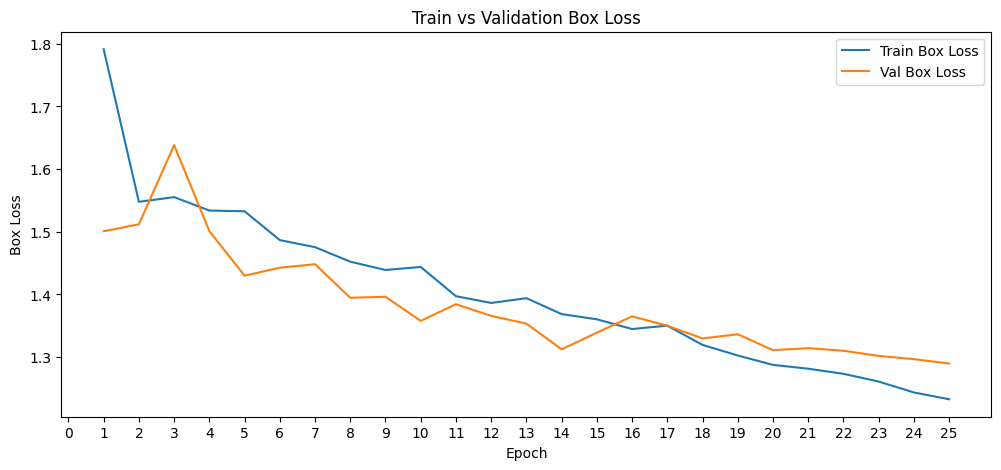

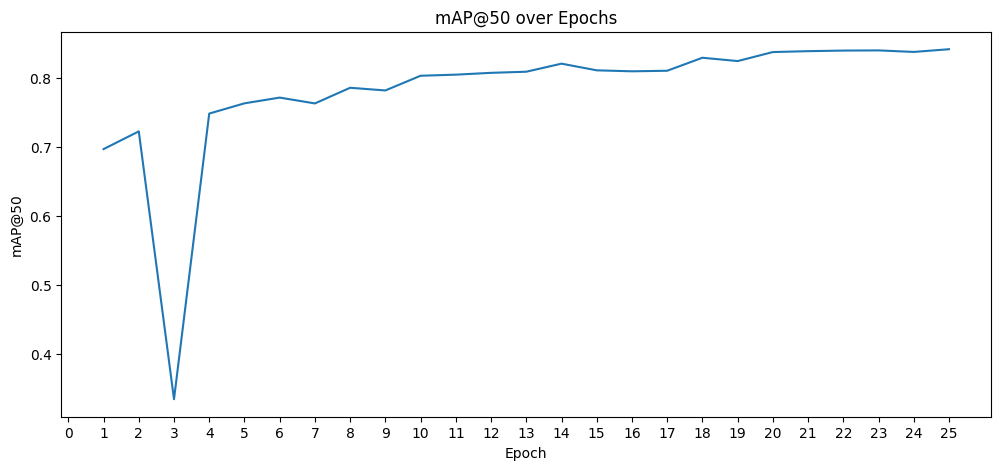

In [ ]:
import numpy as np
plt.figure(figsize=(12,5))
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Train vs Validation Box Loss")
plt.legend()
plt.xticks(np.arange(0,26))
plt.show()
plt.figure(figsize=(12,5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("mAP@50 over Epochs")
plt.xticks(np.arange(0,26))
plt.show()

The val loss generally followed train loss as noticed from the graph which shows that the model was learning consistently without severe overfitting.

The model kept on improving steadily across epochs but eventually hit a plateau near the end. This is inferred from the mAP@50 vs Epoch graph where the line initially kept increasing but became stable(almost horizontal) by the 24th or 25th epoch.

In [ ]:
model=YOLO("/content/runs/detect/building_detector/weights/best.pt")
metrics=model.val(data="dataset/dataset.yaml",split="test")
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
f1 = (2*metrics.box.mp*metrics.box.mr)/(metrics.box.mp+metrics.box.mr+ 1e-6)
print("F1 Score:", f1)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 78.9±25.8 MB/s, size: 947.9 KB)
val: Scanning /content/dataset/labels/test... 115 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 148.5it/s 0.8s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.6s
                   all        115       1805      0.841      0.745      0.821      0.503
Speed: 10.2ms preprocess, 10.5ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.821231684480815
Precision: 0.8412121873633478
Recall: 0.7445983379501385
F1 Score: 0.7899617155958406


| Metric    | Your Value | What it means in plain English                                                 |
| --------- | ---------- | ------------------------------------------------------------------------------ |
| mAP@50    | 0.821      | The model correctly detects buildings with reasonably accurate bounding boxes. |
| Precision | 0.841      | Most predicted buildings are actually correct detections.                      |
| Recall    | 0.745      | The model successfully finds many buildings but still misses some.             |
| F1 Score  | 0.790      | This represents the balance between precision and recall.                      |


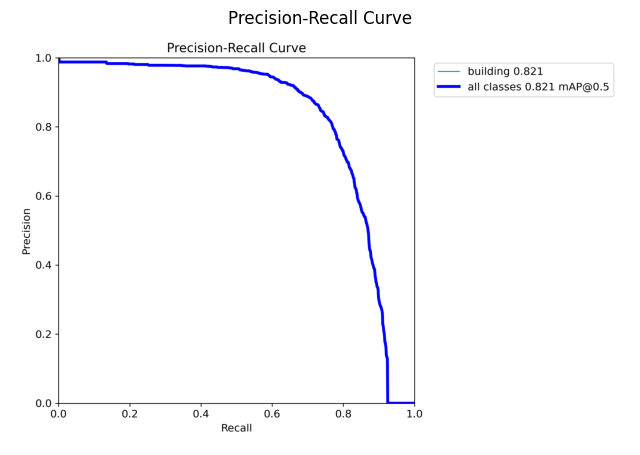

In [ ]:
import matplotlib.image as mpimg
pr_curve=mpimg.imread("/content/runs/detect/val/BoxPR_curve.png")
plt.figure(figsize=(8,8))
plt.imshow(pr_curve)
plt.axis("off")
plt.title("Precision-Recall Curve")
plt.show()

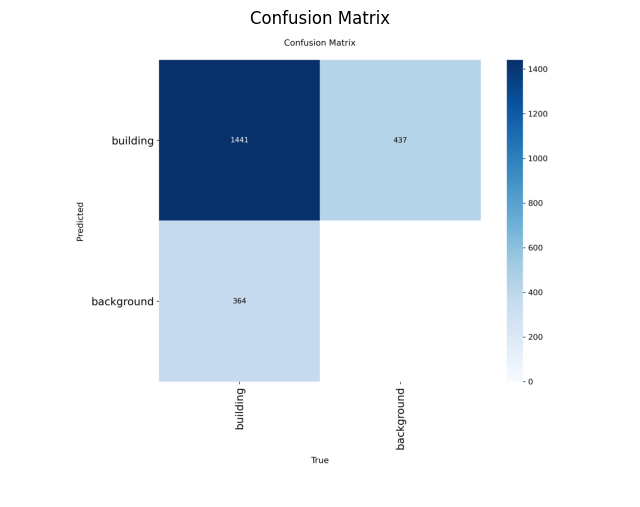

In [ ]:
c_matrix=mpimg.imread("/content/runs/detect/val/confusion_matrix.png")
plt.figure(figsize=(8,8))
plt.imshow(c_matrix)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

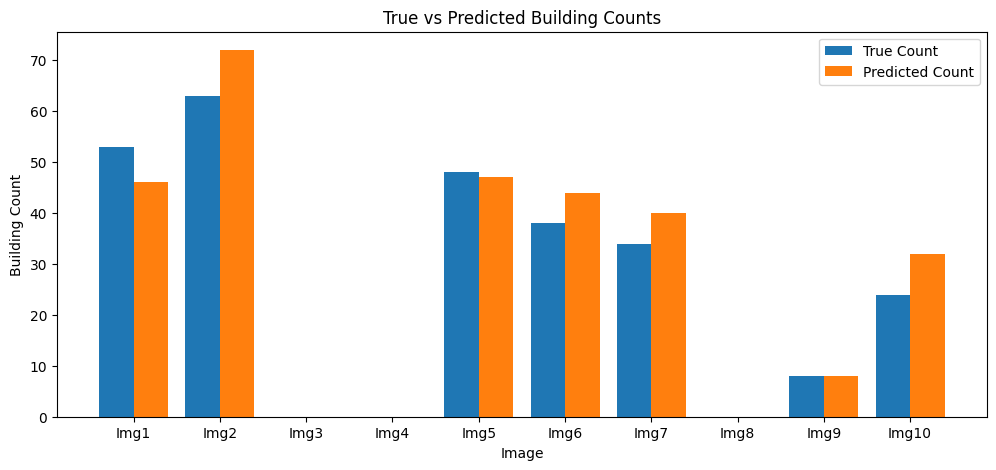

Mean Absolute Error: 3.7


In [ ]:
from sklearn.metrics import mean_absolute_error
model=YOLO("/content/runs/detect/building_detector/weights/best.pt")
random.seed(42)
test_imgs=random.sample(glob.glob("/content/dataset/images/test/*.png"),10)
true_counts=[]
pred_counts=[]
for img_path in test_imgs:
    results=model(img_path, verbose=False)
    pred_count=len(results[0].boxes)
    stem=os.path.splitext(os.path.basename(img_path))[0]
    label_path=f"/content/dataset/labels/test/{stem}.txt"
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            true_count = len(f.readlines())
    else:
        true_count=0
    true_counts.append(true_count)
    pred_counts.append(pred_count)
x=np.arange(len(test_imgs))
plt.figure(figsize=(12,5))
plt.bar(x - 0.2, true_counts, width=0.4, label="True Count")
plt.bar(x + 0.2, pred_counts, width=0.4, label="Predicted Count")
plt.xticks(x, [f"Img{i+1}" for i in range(len(test_imgs))])
plt.xlabel("Image")
plt.ylabel("Building Count")
plt.title("True vs Predicted Building Counts")
plt.legend()
plt.show()
mae=mean_absolute_error(true_counts, pred_counts)
print("Mean Absolute Error:", round(mae, 3))

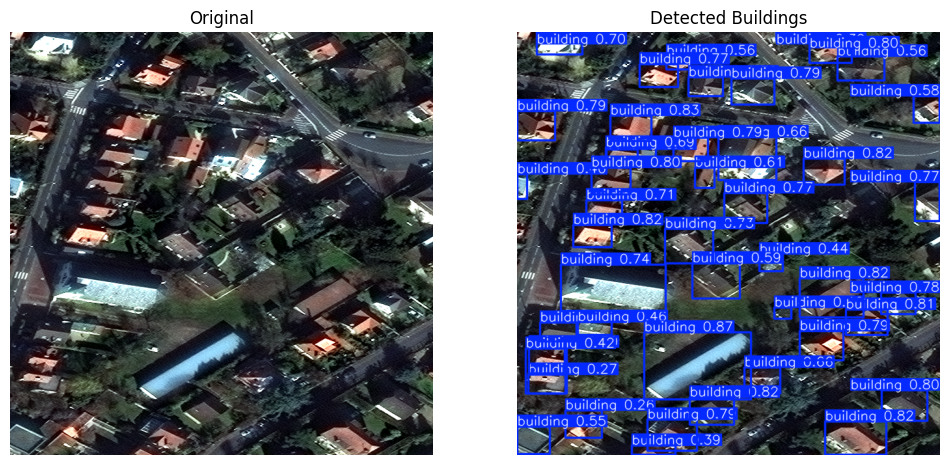

Image: AOI_3_Paris_img1311.png
Buildings detected: 46
Avg confidence: 0.65
Processing time: 136.0 ms


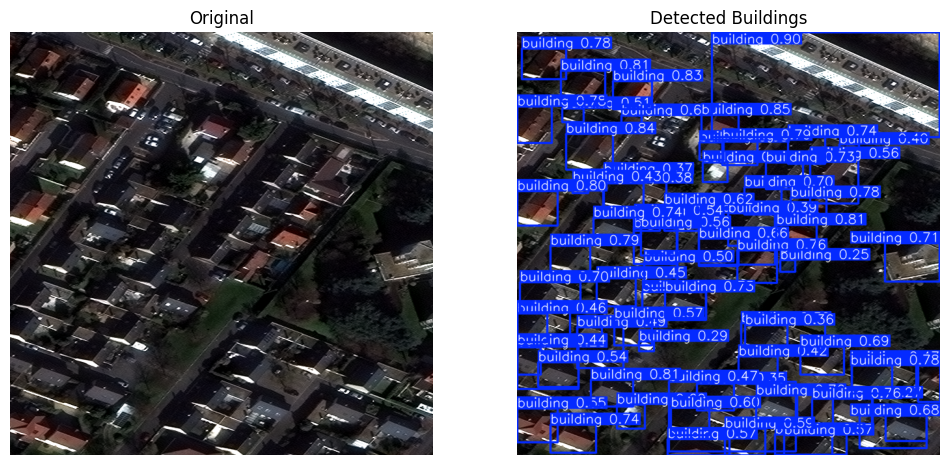

Image: AOI_3_Paris_img731.png
Buildings detected: 72
Avg confidence: 0.58
Processing time: 41.2 ms


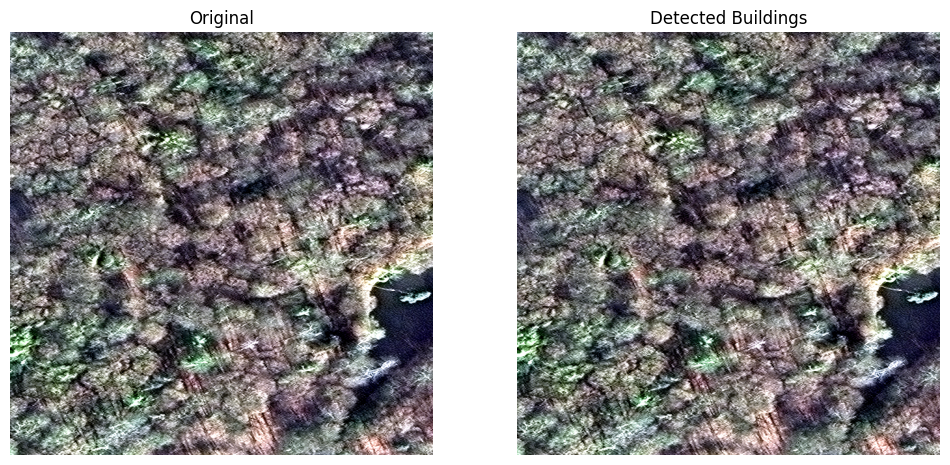

Image: AOI_3_Paris_img1747.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 33.8 ms


In [ ]:
import time
model=YOLO("/content/runs/detect/building_detector/weights/best.pt")
def final_pipeline(image_path):
    start=time.time()
    results=model(image_path, verbose=False)
    end=time.time()
    boxes=results[0].boxes
    count=len(boxes)
    if count:
        avg_conf=float(boxes.conf.mean())
    else:
        avg_conf = 0.0
    processing_time=(end - start) * 1000
    annotated=results[0].plot()
    original=cv2.imread(image_path)
    original=cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    annotated=cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(annotated)
    plt.title("Detected Buildings")
    plt.axis("off")
    plt.show()
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {count}")
    print(f"Avg confidence: {avg_conf:.2f}")
    print(f"Processing time: {processing_time:.1f} ms")

random.seed(42)
test_images=glob.glob("/content/dataset/images/test/*.png")
sample_images=random.sample(test_images, 3)
for img in sample_images:
    final_pipeline(img)